## The pilot's horizon: what a 200-encounter calibration run cannot see

The validation campaign calibrates each condition's shell ladder from a short Monte-Carlo pilot
(`scripts/validation/campaign.py`, `_ladder_for`) run on 200 encounters. A sample that size
resolves the min-separation CDF down to about its own smallest draw — the ~1/200 ≈ 5e-3
quantile — and no further; every shell placed below that point is extrapolation, not observation.
This notebook runs the campaign's own machinery on one geometry and one noise rung to show where
that horizon actually sits, how much further the true tail reaches below it, and what the
extrapolated shells look like once an IPS run has to cross them. The full argument is in
`vault/observations/important-pilot-horizon-fixed-ladders.md`.

In [1]:
%matplotlib inline
import math
import statistics
import sys
import pathlib

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

REPO = pathlib.Path("/Users/mfrahman/Projects/OpenCDaRR")
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts" / "validation"))

from campaign import methods_for, base_config, SHELL_RATIO, FINAL_GAP, MAX_SHELLS, RPZ
from opencdarr.scenario import PairwiseEncounter
from opencdarr.experiment import MC, IPS, Fixed, run_experiment

scenario = PairwiseEncounter(dpsi=180.0, dcpa=0.0)
POS_CI95 = 20.0
DECL = {"pos_ci95": Fixed(POS_CI95), "vel_ci95": Fixed(POS_CI95 / 10.0)}

## The pilot

200 encounters, run exactly as `_ladder_for` runs its own pilot: same scenario, same declaration,
same backend. The geometry is a head-on pairwise encounter (`dpsi=180`, `dcpa=0`) at 20 m GNSS
self-noise — between the campaign's 40 m anchor rung and its 10 m target rung, chosen so the loss
probability lands a few decades below the horizon without needing a very large truth run to see
it.

In [2]:
pilot = run_experiment(
    DECL, methods=methods_for(scenario), backend=MC(n_encounters=200),
    base_config=base_config(200, POS_CI95), seed=1, n_jobs=-1,
).cell()

seps = np.sort(np.array(pilot.min_seps))
horizon_d = float(seps[0])
print(f"{len(seps)} encounters, {pilot.n_los} losses, smallest min_sep = {horizon_d:.1f} m")

200 encounters, 0 losses, smallest min_sep = 61.4 m


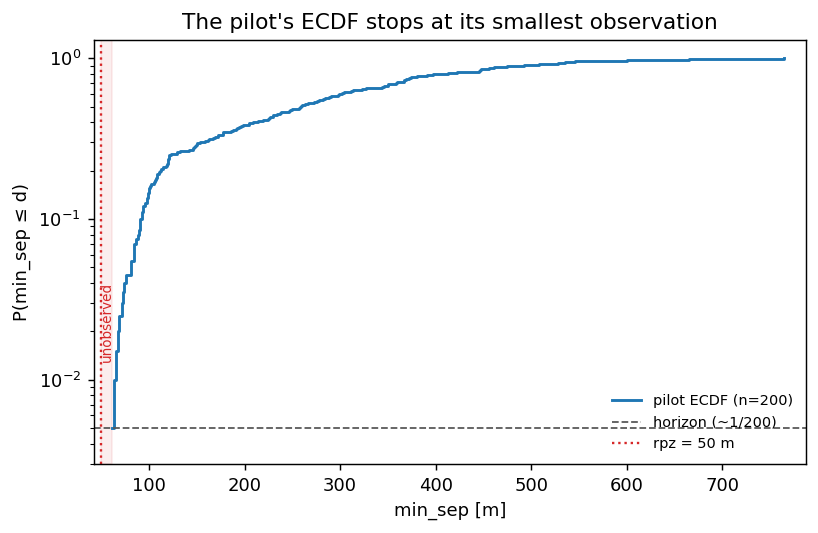

In [3]:
ecdf_y = np.arange(1, len(seps) + 1) / len(seps)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.set_ylim(3e-3, 1.3)
ax.axvspan(RPZ, horizon_d, color="tab:red", alpha=0.08)
ax.step(seps, ecdf_y, where="post", color="tab:blue", lw=1.6, label=f"pilot ECDF (n={len(seps)})")
ax.axhline(5e-3, color="0.35", lw=1.0, ls="--", label="horizon (~1/200)")
ax.axvline(RPZ, color="tab:red", lw=1.3, ls=":", label=f"rpz = {RPZ:.0f} m")
ax.text((RPZ + horizon_d) / 2, 2.3e-2, "unobserved", rotation=90, ha="center", va="center",
        fontsize=7.5, color="tab:red")
ax.set_yscale("log")
ax.set_xlim(RPZ - 8, seps[-1] * 1.03)
ax.set_xlabel("min_sep [m]")
ax.set_ylabel("P(min_sep ≤ d)")
ax.set_title("The pilot's ECDF stops at its smallest observation")
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

200 samples resolve the CDF down to about the 1/200 ≈ 5e-3 quantile — the horizontal
line — and no further; the step function has no data below its own smallest draw. The
shaded strip between that draw and `rpz` is the region the pilot cannot see. It looks narrow here,
about 11 m, but narrow in metres is not the same as narrow in probability — that is what the
next figure is for.

## Below the horizon

A larger run of the same declaration — 60,000 encounters, same everything else but the seed
and the count — resolves the CDF much further down. Overlay it on the pilot's own curve.

In [4]:
N_BIG = 60000

truth = run_experiment(
    DECL, methods=methods_for(scenario), backend=MC(n_encounters=N_BIG),
    base_config=base_config(N_BIG, POS_CI95), seed=0, n_jobs=-1,
).cell()

seps_truth = np.sort(np.array(truth.min_seps))
n_below_55 = int(np.searchsorted(seps_truth, 55.0, side="right"))
print(f"{N_BIG} encounters, {truth.n_los} at or below rpz, {n_below_55} within 55 m, "
      f"P_hat(LoS) = {truth.p_los_run:.3e}")

60000 encounters, 8 at or below rpz, 32 within 55 m, P_hat(LoS) = 1.333e-04


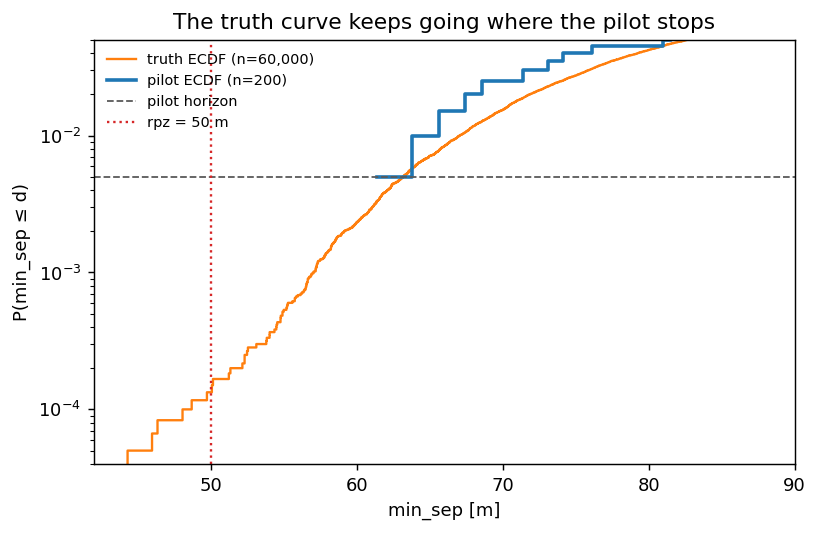

In [5]:
ecdf_truth_y = np.arange(1, len(seps_truth) + 1) / len(seps_truth)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.step(seps_truth, ecdf_truth_y, where="post", color="tab:orange", lw=1.3,
        label=f"truth ECDF (n={N_BIG:,})")
ax.step(seps, ecdf_y, where="post", color="tab:blue", lw=2.0, label=f"pilot ECDF (n={len(seps)})")
ax.axhline(5e-3, color="0.35", lw=1.0, ls="--", label="pilot horizon")
ax.axvline(RPZ, color="tab:red", lw=1.3, ls=":", label=f"rpz = {RPZ:.0f} m")
ax.set_yscale("log")
ax.set_xlim(RPZ - 8, 90)
ax.set_ylim(4e-5, 0.05)
ax.set_xlabel("min_sep [m]")
ax.set_ylabel("P(min_sep ≤ d)")
ax.set_title("The truth curve keeps going where the pilot stops")
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

The pilot's staircase (blue) and the truth curve (orange) agree everywhere the pilot has data;
below its horizon the truth curve is the only one with anything to say, and it keeps descending
for about a decade and a half before it reaches `rpz`. Worth saying plainly: this is a
60,000-encounter run and it still only sees 8 crossings of `rpz` itself (32 within 55 m) —
the tail near the boundary is real but thin, and the curve's exact shape down there carries real
sampling noise of its own. It is a much better view of the region than the pilot's zero
observations, not a noise-free one.

## The ladder still has to cross it

`_ladder_for` builds shells geometrically from the pilot's own median down to `rpz`: start at the
median, close 62% of whatever is left at each step, stop once a step would land within
`FINAL_GAP` of the boundary. Reproduce that rule directly (not by importing the private function),
then run a small IPS on the result.

In [6]:
start = statistics.median(pilot.min_seps)
span = start - RPZ
count = max(1, math.ceil(1 + math.log(FINAL_GAP / span) / math.log(SHELL_RATIO)))
count = min(count, MAX_SHELLS - 1)
shells = [round(RPZ + span * SHELL_RATIO**k, 1) for k in range(count)] + [RPZ]

n_below_horizon = sum(d < horizon_d for d in shells)
print(f"{len(shells)} shells, {n_below_horizon} of them below the pilot horizon:")
print(shells)

ips = run_experiment(
    DECL, methods=methods_for(scenario), backend=IPS(shells=shells, n_particles=400, reps=4),
    base_config=base_config(400, POS_CI95), seed=0, n_jobs=-1,
).cell()
print(f"P_hat(LoS) IPS = {ips.p_los_run:.3e}, {ips.n_collapsed} of 4 replications collapsed")

13 shells, 6 of them below the pilot horizon:
[258.6, 179.4, 130.2, 99.7, 80.8, 69.1, 61.9, 57.3, 54.6, 52.8, 51.8, 51.1, 50.0]


P_hat(LoS) IPS = 2.926e-04, 0 of 4 replications collapsed


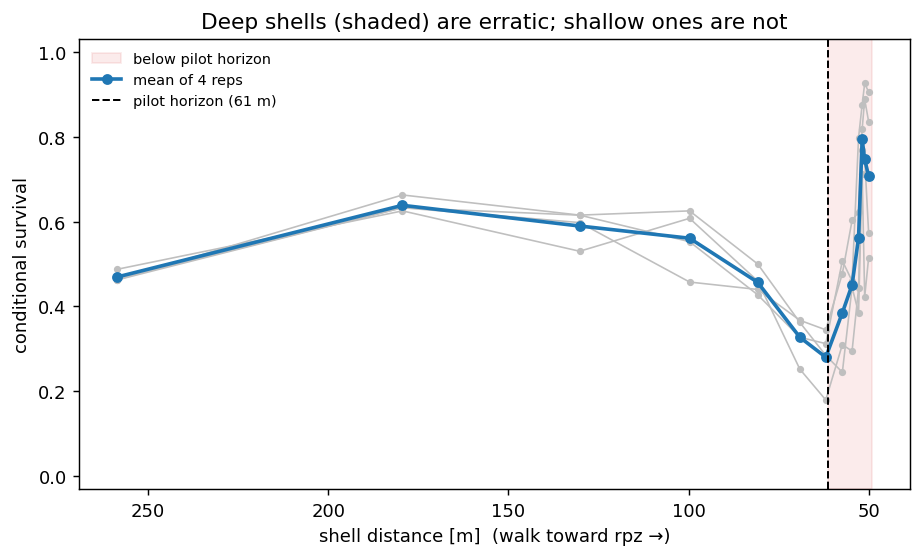

In [7]:
survival = np.array([r.survival for r in ips.reps])
mean_survival = survival.mean(axis=0)
shell_x = np.array(ips.reps[0].levels)

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.axvspan(RPZ - 1, horizon_d, color="tab:red", alpha=0.09, zorder=0, label="below pilot horizon")
for rep_s in survival:
    ax.plot(shell_x, rep_s, color="0.75", lw=0.9, marker="o", ms=3, zorder=1)
ax.plot(shell_x, mean_survival, color="tab:blue", lw=2.0, marker="o", ms=5, zorder=2,
        label="mean of 4 reps")
ax.axvline(horizon_d, color="k", lw=1.1, ls="--", label=f"pilot horizon ({horizon_d:.0f} m)")
ax.invert_xaxis()
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("shell distance [m]  (walk toward rpz →)")
ax.set_ylabel("conditional survival")
ax.set_title("Deep shells (shaded) are erratic; shallow ones are not")
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

Survival is smooth above the horizon — a climb, then a shallow dip — and ragged
below it: the four replications fan out from each other exactly where the shells sit inside the
region the pilot never measured, because that spacing came from a formula extrapolating off a
median, not from anything observed there. None of these four replications collapsed outright, but
the spread between them is doing what the observation note describes: the resolver contests every
metre below roughly 55–60 m, and a shell dropped blindly into that territory can land
anywhere from starved to trivial.

## Summary

In [8]:
rows = [
    ("pilot horizon (~1/200 quantile)", f"{horizon_d:.1f} m"),
    (f"P_hat(LoS), big MC (n={N_BIG:,})", f"{truth.p_los_run:.3e}"),
    ("P_hat(LoS), IPS (400 particles x 4 reps)", f"{ips.p_los_run:.3e}"),
    ("shells in ladder", f"{len(shells)}"),
    ("shells below the pilot horizon", f"{n_below_horizon}"),
]
width = max(len(label) for label, _ in rows)
for label, value in rows:
    print(f"{label:<{width}}  {value}")

pilot horizon (~1/200 quantile)           61.4 m
P_hat(LoS), big MC (n=60,000)             1.333e-04
P_hat(LoS), IPS (400 particles x 4 reps)  2.926e-04
shells in ladder                          13
shells below the pilot horizon            6


Probability-spaced shells would tighten the shallow half of this ladder but leave the deep half
just as erratic — the full argument, and why the real fix (adaptive multilevel splitting)
stays deferred, is in `vault/observations/important-pilot-horizon-fixed-ladders.md`.